# Lab 4: Code Interpreter Agent — Claims Analytics
---
**SmartClaims AI Agent** | Microsoft Foundry Agent Service (v2.x)

## Objective
Use the Code Interpreter tool to let your agent write and execute Python code in a secure sandbox. You’ll learn:
- Uploading data files for agent analysis
- Configuring **CodeInterpreterTool** with a sandboxed Python environment
- Running data analytics queries (pandas, matplotlib)
- Downloading generated charts and visualizations

## Architecture
```
CSV Upload → Sandbox Container (pandas, matplotlib) → Agent writes Python → Executes in sandbox → Returns insights + charts
```

> 💡 **Code Interpreter** runs Python in an isolated sandbox. The agent writes code, the sandbox executes it, and results (text, charts, data) are returned. Your data never leaves the secure environment.

## Step 1: Import Dependencies & Create Clients

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from utils.config import (
    get_clients, MODEL, CLAIMS_CSV, OUTPUTS_DIR,
    print_header, print_step,
)
from azure.ai.projects.models import (
    PromptAgentDefinition,
    CodeInterpreterTool,
    CodeInterpreterContainerAuto,
)

project_client, openai_client = get_clients()
print("✅ Clients created")

✅ Clients created


## Step 2: Upload Claims CSV

The `purpose="assistants"` flag tells the service this file is for agent use in a sandbox environment. The file will be available inside the Code Interpreter’s Python environment.

In [2]:
file = openai_client.files.create(
    purpose="assistants",
    file=open(str(CLAIMS_CSV), "rb"),
)
print(f"✅ File uploaded: {file.id}")

# The 'purpose' parameter in the file upload process is used to categorize the file for a specific use case. 
# In this context, setting the purpose to "assistants" indicates that the uploaded file is intended to be used by AI assistants, 
# such as the PromptAgent we are creating. This categorization can help the system understand how to utilize the file and
# may have functional implications in terms of how the file is accessed and processed by the assistant.

# what if we dont use the 'purpose' parameter?
# If you don't use the 'purpose' parameter when uploading a file, the system may not
# categorize the file correctly, which could lead to issues when trying to access or utilize the file in specific contexts, 
# such as with AI assistants. 
# The file may still be uploaded successfully, but it might not be available for use in the intended scenarios, 
# or it could cause errors when the assistant tries to access it.

✅ File uploaded: assistant-RqErt1yDBwhhYFCvwSMNVx


## Step 3: Configure Code Interpreter

**`CodeInterpreterContainerAuto`** creates a Python sandbox with your CSV pre-loaded. The agent can:
- Read the CSV using `pandas`
- Perform statistical analysis
- Create charts with `matplotlib`
- Save outputs as PNG files

The sandbox comes pre-installed with common data science packages.

In [3]:
code_interpreter = CodeInterpreterTool(
    container=CodeInterpreterContainerAuto(file_ids=[file.id])
)
print("✅ Sandbox configured with claims CSV")

✅ Sandbox configured with claims CSV


## Step 4: Create the Analytics Agent

The agent instructions specify:
- Available columns in the dataset
- Preferred tools (pandas for analysis, matplotlib for charts)
- Output format (executive-summary style with numbers)
- Chart saving requirement (PNG format)

In [ ]:
agent = project_client.agents.create_version(
    agent_name="smartclaims-analytics",
    definition=PromptAgentDefinition(
        model=MODEL,
        instructions=(
            "You are SmartClaims Analytics Agent for Contoso Insurance. "
            "You have a claims CSV dataset. Columns: claim_id, "
            "policy_number, policyholder_name, claim_date, incident_date, "
            "incident_type, claim_amount, approved_amount, status, "
            "adjuster_name, fraud_flag, fraud_score, region, policy_type, "
            "deductible, settlement_date, processing_days. "
            "Use pandas for analysis and matplotlib for charts. "
            "When creating charts, always save them as PNG files. "
            "Provide executive-summary style insights with numbers."
        ),
        tools=[code_interpreter],
    ),
)
print(f"Agent: {agent.name} v{agent.version}")

# why is the agent not showing up in the UI?
# If the agent is not showing up in the UI, there could be several reasons for this
# 1. Deployment Delay: Sometimes, there can be a delay between when the agent is created and when it becomes visible in the UI.
# 2. Permissions: Ensure that you have the necessary permissions to view the agent in the
#    UI. If the agent was created under a different account or project, it may not be visible to you.
# 3. UI Refresh: Try refreshing the UI or logging out and back in to see
#    if the agent appears.


Agent: smartclaims-analytics v1


## Step 5: Run Analytics Queries

We’ll run 5 different analytics queries, each demonstrating a different capability:

1. **Executive Summary** — Basic statistics and distributions
2. **Visualization** — Bar chart of claims by incident type
3. **Fraud Analysis** — Breakdown by region and incident type
4. **Processing Analysis** — Performance metrics by status and region
5. **Top Claims** — Highest-value claims with fraud indicators

In [5]:
conversation = openai_client.conversations.create()

def ask(q):
    """Send an analytics query to the agent."""
    return openai_client.responses.create(
        conversation=conversation.id,
        extra_body={"agent_reference": {
            "name": agent.name, "version": agent.version,
            "type": "agent_reference"}},
        input=q,
    )

### Analysis 1: Executive Summary

In [6]:
r1 = ask(
    "Load the CSV. Give an executive summary: total claims, "
    "total amount, average amount, status distribution."
)
print(f"📊 {r1.output_text}")

📊 ### Executive Summary of Claims Data

- **Total Claims Processed**: 500
- **Total Claim Amount**: $58,844,120.69
- **Average Claim Amount**: $117,688.24

#### Status Distribution of Claims:
- **Settled**: 113 claims
- **Under Review**: 105 claims
- **Pending**: 100 claims
- **Denied**: 91 claims
- **Approved**: 91 claims

This summary provides an overview of the claims processed, highlighting the financial implications and the current status distribution.


In [7]:
r1 = ask(
    "who are the top 5 policyholders by claim amount? Provide a bar chart of their claim amounts."
)
print(f"📊 {r1.output_text}")

📊 ### Top 5 Policyholders by Claim Amount

| Policyholder Name | Total Claim Amount |
|-------------------|--------------------|
| Customer_0474     | $485,110.51        |
| Customer_0385     | $483,367.17        |
| Customer_0050     | $482,713.18        |
| Customer_0369     | $474,154.40        |
| Customer_0014     | $473,955.85        |

#### Bar Chart
![Top 5 Policyholders by Claim Amount](sandbox:/mnt/data/top_policyholders_claim_amounts.png)

You can [download the bar chart here](sandbox:/mnt/data/top_policyholders_claim_amounts.png).


In [8]:
r1 = ask(
    "give me top 5 claims by jalal"
)
print(f"📊 {r1.output_text}")

📊 It seems there are no claims associated with the adjuster named "Jalal" in the dataset. Would you like to check for claims by a different adjuster or perhaps look at another aspect of the data?


### Analysis 2: Claims by Incident Type (Bar Chart)

In [10]:
r2 = ask(
    "Create a bar chart of claims count by incident type. "
    "Use professional colors as used by EY company theme. Save the chart as a PNG file. Use legends and title and whatever is needed to make it look professional."
)
print(f"📊 {r2.output_text}")

📊 ### Claims Count by Incident Type

A professional bar chart has been created using the EY color theme, showcasing the number of claims per incident type.

You can [download the chart here](sandbox:/mnt/data/claims_count_by_incident_type_ey_theme.png).


### Analysis 3: Fraud Analysis

In [11]:
r3 = ask(
    "Analyze fraud: what % are flagged? Break down fraud "
    "rates by region and by incident type."
)
print(f"📊 {r3.output_text}")

📊 ### Fraud Analysis Summary

- **Percentage of Claims Flagged as Fraud**: **7.2%**

#### Fraud Rates by Region:
- **Central**: 5.22%
- **East**: 8.49%
- **North**: 13.04%
- **South**: 8.54%
- **West**: 1.90%

#### Fraud Rates by Incident Type:
- **Auto Collision**: 4.05%
- **Fire Damage**: 4.05%
- **Liability**: 8.11%
- **Medical Claim**: 10.17%
- **Natural Disaster**: 7.69%
- **Property Damage**: 7.59%
- **Theft**: 9.33%

This analysis reveals significant fraud presence in certain regions and incident types, with the North region and Medical Claims showing the highest rates.


### Analysis 4: Processing Time Analysis

In [12]:
r4 = ask(
    "Average processing days by status and region. "
    "Which region resolves claims fastest?"
)
print(f"📊 {r4.output_text}")

📊 ### Average Processing Days by Status and Region

| Status         | Central | East  | North | South | West  |
|----------------|---------|-------|-------|-------|-------|
| **Approved**   | 47.71   | 50.00 | 48.05 | 49.63 | 46.44 |
| **Denied**     | 44.00   | 46.00 | 45.59 | 47.83 | 34.16 |
| **Pending**    | 16.85   | 13.73 | 13.93 | 20.06 | 19.95 |
| **Settled**    | 52.88   | 47.55 | 51.94 | 45.06 | 51.67 |
| **Under Review**| 14.67  | 13.00 | 14.00 | 16.21 | 16.48 |

### Fastest Resolving Region
The **East** region resolves claims the fastest, with an average processing time of **13.0 days** for claims in the "Under Review" status. 

If you need further analysis or breakdowns, feel free to ask!


### Analysis 5: Top 10 Highest Claims

In [13]:
r5 = ask(
    "Top 10 highest claims — show claim ID, type, amount, "
    "status, and fraud score."
)
print(f"📊 {r5.output_text}")

📊 ### Top 10 Highest Claims

| Claim ID  | Incident Type       | Claim Amount | Status        | Fraud Score |
|-----------|---------------------|--------------|---------------|-------------|
| CLM-0474  | Natural Disaster     | $485,110.51  | Approved      | 0.16        |
| CLM-0385  | Natural Disaster     | $483,367.17  | Settled       | 0.38        |
| CLM-0050  | Natural Disaster     | $482,713.18  | Denied        | 0.37        |
| CLM-0369  | Natural Disaster     | $474,154.40  | Under Review  | 0.40        |
| CLM-0014  | Natural Disaster     | $473,955.85  | Settled       | 0.18        |
| CLM-0033  | Natural Disaster     | $470,226.20  | Under Review  | 0.11        |
| CLM-0331  | Natural Disaster     | $465,805.97  | Approved      | 0.08        |
| CLM-0178  | Natural Disaster     | $457,270.48  | Pending       | 0.28        |
| CLM-0202  | Natural Disaster     | $451,623.75  | Denied        | 0.20        |
| CLM-0300  | Natural Disaster     | $448,786.66  | Settled       | 0.1

## Step 6: Download Generated Charts

Charts created by the agent in the sandbox can be downloaded. Let’s check for any generated PNG files.

In [14]:
responses = [r1, r2, r3, r4, r5]
chart_count = 0
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

for resp in responses:
    try:
        for item in resp.output:
            if not hasattr(item, "content"):
                continue
            for block in item.content:
                if hasattr(block, "type") and block.type == "image":
                    if hasattr(block, "image") and hasattr(block.image, "file_id"):
                        fid = block.image.file_id
                        cid = getattr(block.image, "container_id", None)
                        chart_count += 1
                        fname = f"chart_{chart_count}_{fid}.png"
                        print(f"📥 Chart found: {fid}")
                        if cid:
                            content = openai_client.containers.files.content.retrieve(
                                container_id=cid, file_id=fid,
                            )
                            path = OUTPUTS_DIR / fname
                            with open(str(path), "wb") as f:
                                f.write(content.read())
                            print(f"✅ Saved: {path.name}")

                if hasattr(block, "annotations"):
                    for ann in block.annotations:
                        if hasattr(ann, "container_id") and hasattr(ann, "file_id"):
                            chart_count += 1
                            fname = f"chart_{chart_count}_{ann.file_id}.png"
                            print(f"📥 Chart found: {ann.file_id}")
                            content = openai_client.containers.files.content.retrieve(
                                container_id=ann.container_id,
                                file_id=ann.file_id,
                            )
                            path = OUTPUTS_DIR / fname
                            with open(str(path), "wb") as f:
                                f.write(content.read())
                            print(f"✅ Saved: {path.name}")
    except Exception as e:
        print(f"ℹ️  Error extracting chart: {e}")

if chart_count == 0:
    print("ℹ️  No downloadable charts found.")
    print("💡 Charts may have been rendered inline in the sandbox.")

📥 Chart found: cfile_69c938418be081909ac48a6ad80dd72a
✅ Saved: chart_1_cfile_69c938418be081909ac48a6ad80dd72a.png
📥 Chart found: cfile_69c93842e6208190a2da4b0478498ebe
✅ Saved: chart_2_cfile_69c93842e6208190a2da4b0478498ebe.png


chart_1_cfile_69c938418be081909ac48a6ad80dd72a.png


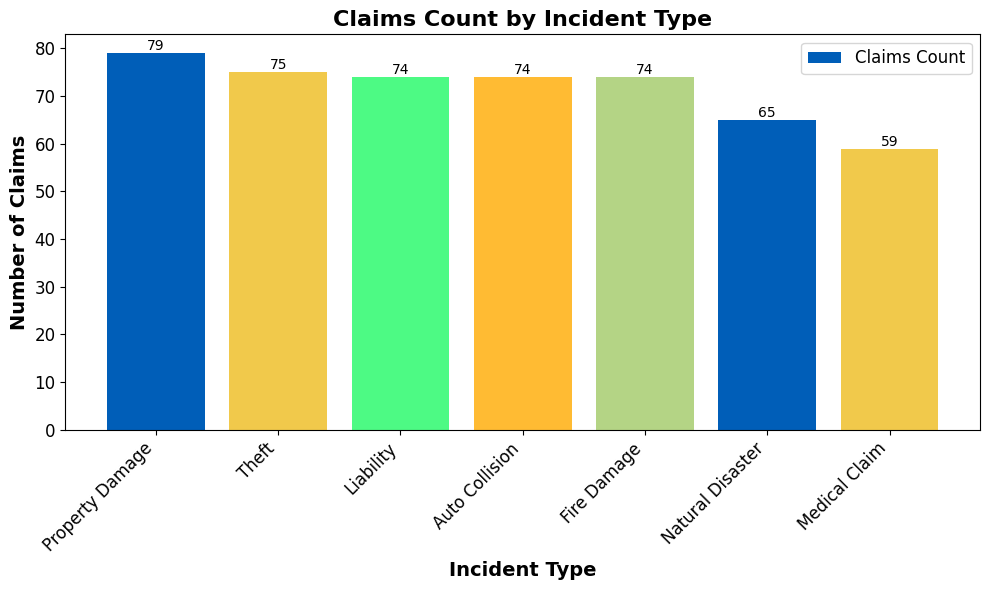

chart_2_cfile_69c93842e6208190a2da4b0478498ebe.png


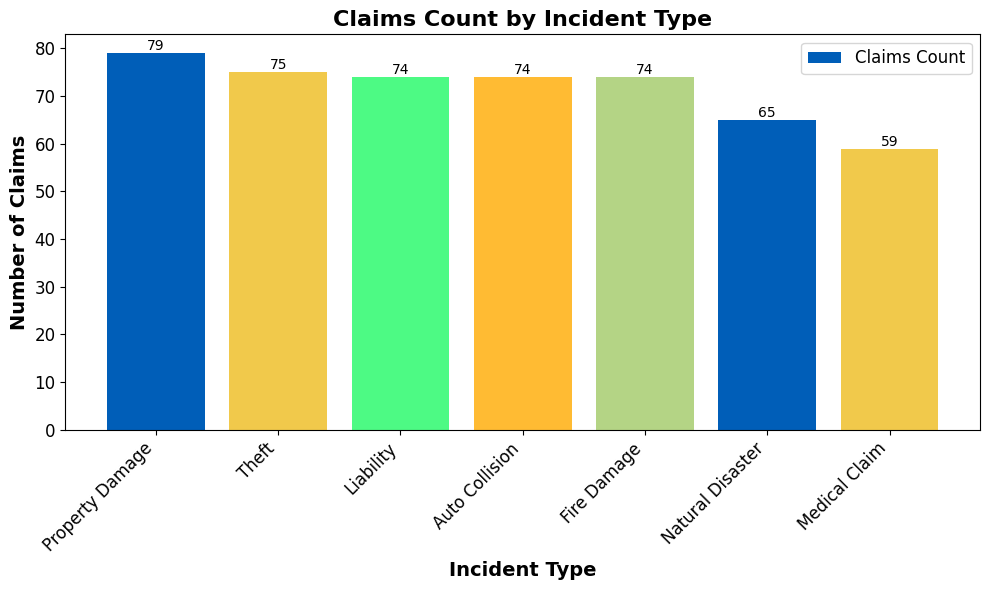

In [15]:
from IPython.display import Image, display

for f in OUTPUTS_DIR.glob("*.png"):
    print(f.name)
    display(Image(filename=str(f)))

## Step 7: Clean Up

In [16]:
project_client.agents.delete(agent.name)
print("✅ Agent deleted")

✅ Agent deleted


## ✅ Lab 4 Complete!

### Key Takeaways
| Concept | What You Learned |
|---------|------------------|
| CodeInterpreterTool | Sandboxed Python execution for data analysis |
| CodeInterpreterContainerAuto | Auto-provisioned container with pre-loaded files |
| File Upload | `purpose="assistants"` makes files available to agents |
| Chart Generation | Agent creates matplotlib charts, downloadable as PNG |
| Executive Insights | Combine code execution with natural language summaries |

### When to Use Code Interpreter
- **Data analysis** — CSV/Excel analysis with pandas
- **Visualizations** — Charts and graphs with matplotlib
- **Calculations** — Complex math, statistics, aggregations
- **File processing** — Transform, filter, or summarize data files

---
**Next →** [Lab 5: Function Tools](lab5_function_tools.ipynb) — Add custom business logic as agent tools